# 17_机器学习模型评估方法-ROC 曲线

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


这一小节，咱们来一起看看关于**机器学习模型评估方法-ROC 曲线**的详细内容\~

#### 什么是 ROC 曲线？

ROC 曲线，全称是 **接收者操作特征曲线**（Receiver Operating Characteristic Curve），是**评估二分类模型性能**的一种常见方法。

通俗来讲：ROC 曲线就像是给你的分类模型画一条“体检曲线”，看看在各种判断标准下，它能把“病人”和“正常人”分开的能力强不强。

#### 生活中的例子（简单举例）

假设你有一个模型来预测某人是否患有某种病，输出的结果是一个 0\~1 之间的概率值，比如：

- A 的预测值是 0.95 → 很可能有病
- B 的预测值是 0.1 → 很可能没病

你需要定一个“阈值”（比如 0.5），大于等于这个值你就判为“有病”，否则就是“没病”。

那问题来了：你怎么知道这个“阈值”选得好不好？换不同的阈值，预测效果会怎样？这就是 **ROC 曲线**要回答的问题。

### ROC 曲线的核心概念

#### 二分类问题的四种预测结果

ROC 曲线的核心是四种预测情况：

| 实际情况 | 模型预测是阳性 | 模型预测是阴性 |
|-|-|-|
| 实际为阳性（1） | **真正 (TP)** | **假负 (FN)** |
| 实际为阴性（0） | **假正 (FP)** | **真负 (TN)** |

#### 两个重要指标

- **真正率（True Positive Rate, TPR）**：也叫**召回率**


$$
\text{TPR} = \frac{TP}{TP + FN}
$$


- 意思是：真正预测成阳性的比例（病人被正确识别出来的比例）
- **假正率（False Positive Rate, FPR）**：


$$
\text{FPR} = \frac{FP}{FP + TN}
$$


- 意思是：实际为阴性的样本被错误地判为阳性的比例（正常人被误诊为病人的比例）

#### ROC 曲线的本质

ROC 曲线就是以不同的“阈值”下，模型对应的 **TPR** 和 **FPR** 的点连接起来，画出的一条曲线。

横轴是 FPR（误报率），纵轴是 TPR（查全率）：


$$
\text{X轴：} \quad \text{FPR} = \frac{FP}{FP + TN} \\\text{Y轴：} \quad \text{TPR} = \frac{TP}{TP + FN}
$$


通过改变阈值，记录下每一个 (FPR, TPR) 对，就能画出整条 ROC 曲线。

### ROC 曲线的数学原理与公式推导

#### 1. 模型输出的“打分”视角

假设你的模型输出的是概率分数 $s(x) \in [0, 1]$，表示“属于正类（1）”的可能性。你可以用不同的**阈值** $\theta$ 来决定：

- $s(x) \geq \theta$ → 判为正类
- $s(x) < \theta$ → 判为负类

每次换一个阈值 $\theta$，就可以重新计算一组 TP、FP、TN、FN，进而算出 TPR 和 FPR。

#### 2. ROC 曲线就是函数 $\text{TPR} = f(\text{FPR})$

我们可以把 FPR 看成输入，TPR 看成输出，随着阈值的变化，曲线从 (0,0) 开始，最终到达 (1,1)。

特别情况：

- 完美分类器：ROC 曲线从 (0,0) → (0,1) → (1,1)，弯成直角，表示完美识别。
- 随机分类器：ROC 曲线是对角线 (0,0) → (1,1)，表示分类器跟扔硬币一样。

#### 3. ROC 曲线下的面积 AUC（Area Under Curve）

AUC 是 ROC 曲线下的面积，介于 0\~1 之间，是 ROC 的量化指标：

- AUC = 1 → 完美分类器
- AUC = 0.5 → 跟随机猜差不多
- AUC < 0.5 → 模型反着用了还行（预测方向反了）

数学上，AUC 的概率解释是：

> **AUC 等于一个正样本得分大于一个负样本得分的概率。**

公式化表示为：


$$
\text{AUC} = P(s(x^+) > s(x^-))
$$


其中 $x^+$ 是一个正样本，$x^-$ 是一个负样本，$s(\cdot)$ 是模型的打分函数。

### ROC 曲线的绘制流程（算法步骤）

**输入：**

- 一个二分类模型，对每个样本给出概率打分（不是0或1的硬预测）
- 每个样本的真实标签（1表示正类，0表示负类）

**步骤：**

1. **对所有样本按模型打分降序排序**
2. **遍历所有可能的阈值（例如每一个预测值都作为阈值）**
3. 对于每个阈值 $\theta$：

   - 计算混淆矩阵 TP, FP, TN, FN
   - 计算 TPR 和 FPR
4. **以 FPR 为横轴，TPR 为纵轴，画出 ROC 曲线**
5. **计算曲线下的面积（AUC）**，常用梯形积分方法近似

## 完整案例

我们使用乳腺癌数据集，它是一个二分类问题，目标是预测肿瘤是“良性”还是“恶性”。

我们将使用一个复杂一点的模型（随机森林），并结合：

- 训练、测试划分
- ROC 曲线绘制
- AUC 计算
- 多模型对比

### 第一步：依赖库

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, RocCurveDisplay, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

- `matplotlib` 和 `seaborn` 用于绘图
- `roc_curve` 和 `auc` 是绘制 ROC 曲线和计算 AUC 的核心工具
- `load_breast_cancer` 是 scikit-learn 内置的数据集
- `RandomForestClassifier` 是复杂且常用的模型，用于分类

### 第二步：加载并查看数据

In [3]:
# 加载乳腺癌数据集
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)  # 0 是恶性，1 是良性

# 查看数据维度和基本信息
print(X.shape)
print(X.head())
print(data.target_names)  # ['malignant' 'benign']

(569, 30)
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0 

- `X` 是包含多个肿瘤特征的输入数据
- `y` 是目标变量（是否为恶性）
- 本案例中我们把 “是否为恶性” 作为模型输出的目标（正类为 1）

### 第三步：划分训练集与测试集，并标准化

In [4]:
# 数据划分
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 特征缩放
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

- 划分比例是 70% 训练，30% 测试
- 随机种子设为 42，确保结果可重复
- 标准化能提升模型表现，尤其是对距离敏感的模型

### 第四步：训练模型并输出预测概率

In [5]:
# 构建随机森林模型
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_scaled, y_train)

# 预测概率值
y_proba = clf.predict_proba(X_test_scaled)[:, 1]  # 只取正类概率

- `predict_proba()` 会返回两个概率值：[负类概率，正类概率]
- 我们只需要正类（即恶性肿瘤）的预测概率来绘制 ROC 曲线

### 第五步：计算 ROC 曲线和 AUC

In [6]:
# ROC 曲线计算
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

print(f"AUC值为: {roc_auc:.4f}")

AUC值为: 0.9969


- `roc_curve` 计算出在不同阈值下的 FPR 和 TPR
- `auc` 用来计算 ROC 曲线下的面积，值越接近 1 表示模型性能越好

### 第六步：绘制 ROC 曲线

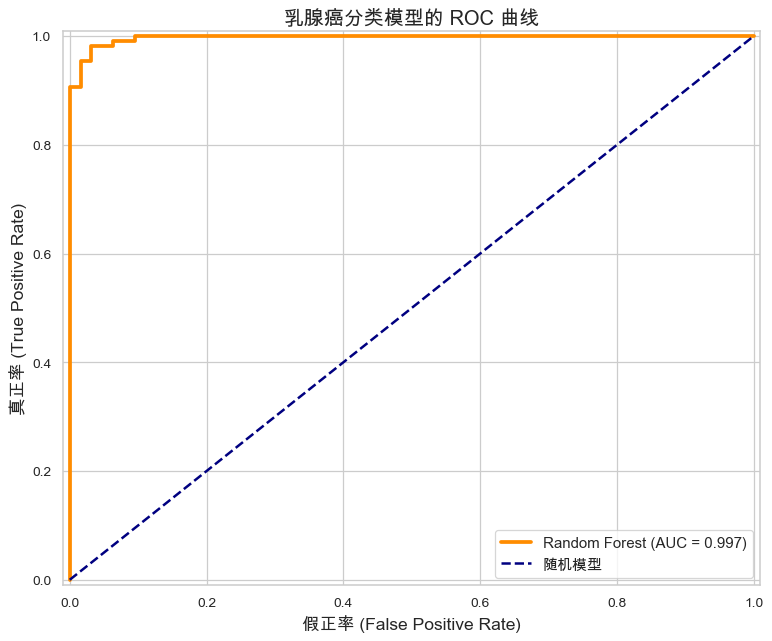

In [7]:
plt.figure(figsize=(10, 8))
sns.set(style="whitegrid")
plt.rcParams['font.sans-serif'] = CJK_FONTS
# ROC 曲线
plt.plot(fpr, tpr, color='darkorange', lw=3, label=f"Random Forest (AUC = {roc_auc:.3f})")

# 随机参考线
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='随机模型')

plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('假正率 (False Positive Rate)', fontsize=14)
plt.ylabel('真正率 (True Positive Rate)', fontsize=14)
plt.title('乳腺癌分类模型的 ROC 曲线', fontsize=16)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True)
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_013.png)

- 加入随机猜测参考线（对角线）

### 第七步：查看混淆矩阵与报告（对比）

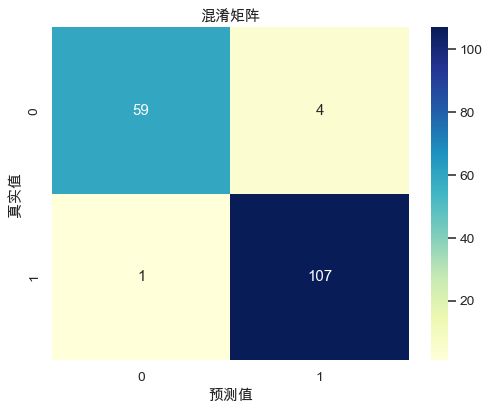

              precision    recall  f1-score   support

   malignant       0.98      0.94      0.96        63
      benign       0.96      0.99      0.98       108

    accuracy                           0.97       171
   macro avg       0.97      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171



In [8]:
# 使用默认0.5阈值做预测
y_pred = (y_proba >= 0.5).astype(int)

# 混淆矩阵
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu')
plt.title("混淆矩阵")
plt.xlabel("预测值")
plt.ylabel("真实值")
plt.show()

# 分类报告
print(classification_report(y_test, y_pred, target_names=data.target_names))

![原文参考图，当前结果见代码输出](attachments/img_014.png)

- 虽然 ROC 曲线与阈值无关，但真实预测还是基于某个阈值（通常是 0.5）
- 混淆矩阵展示了 TP、FP、TN、FN
- `classification_report` 给出了精确率、召回率、F1 分数

### 第八步：扩展对比，添加另一个模型（逻辑回归）

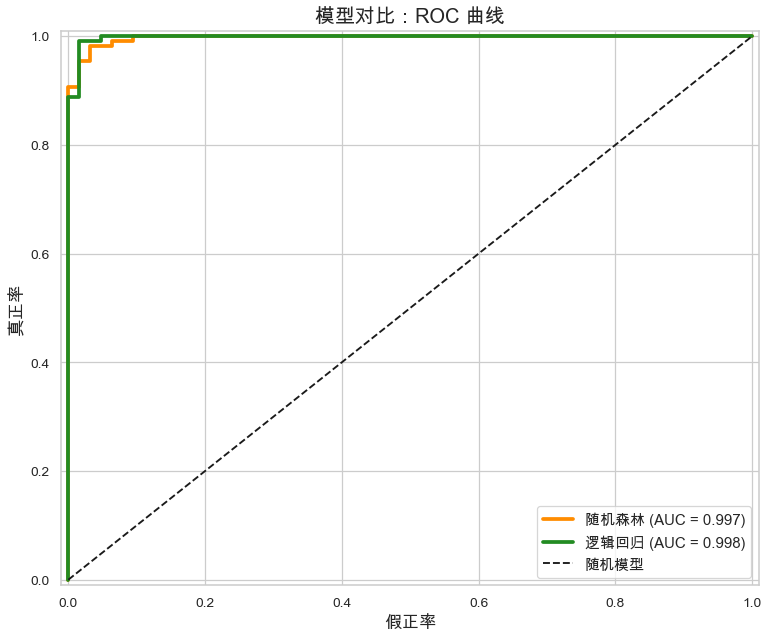

In [9]:
from sklearn.linear_model import LogisticRegression

# 训练逻辑回归
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)
y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]

# ROC 曲线计算
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

# 绘图对比
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=3, label=f"随机森林 (AUC = {roc_auc:.3f})")
plt.plot(fpr_lr, tpr_lr, color='forestgreen', lw=3, label=f"逻辑回归 (AUC = {roc_auc_lr:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label='随机模型')

plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('假正率', fontsize=14)
plt.ylabel('真正率', fontsize=14)
plt.title('模型对比：ROC 曲线', fontsize=16)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True)
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_015.png)

- 对比两个模型的 ROC 曲线可以直观看出哪个模型性能更好
- AUC 更高的模型在分类上总体表现更强

### 使用 ROC 优缺点分析

**优点：**

1. **不受样本类别不均衡影响**：ROC 只关注比率，不关心正负样本数量本身，非常适合不平衡数据。
2. **全面评估模型性能**：相比只用 accuracy 或 precision，ROC 曲线考虑了各种阈值情况。
3. **可视化对比多个模型**：直观对比不同模型或参数下的性能。
4. **数学意义清晰**：AUC 表示任意一个正负样本被正确排序的概率，具备清晰概率解释。

**缺点：**

1. **不反映具体业务代价**：ROC 不考虑正负样本的“代价差异”（比如误诊成本更高时）。
2. **对阈值不敏感**：ROC 本质是阈值无关的，有时你关心的是某个特定阈值下的表现（如精准率）。
3. **多分类问题难扩展**：ROC 曲线最适合二分类，扩展到多分类较复杂。

### 什么时候优选使用 ROC 曲线？

ROC 曲线是以下情况下的首选评估方法：

- 当你有 **二分类问题**，尤其是医疗诊断、欺诈检测等应用中；
- 当你的正负样本 **严重不平衡**，例如恶性肿瘤检测，恶性仅占 1%；
- 当你需要比较 **多个模型的整体性能** 时；
- 当你不关心某个特定阈值的精确率，而想全面评估模型预测能力时；

**不适用情况**：

- 如果你更关心精确率而不是召回率；
- 如果你希望针对特定阈值进行优化；
- 如果是多分类问题且类间不对称，应使用 PR 曲线或多类 AUC 方法。

### 总结

通过乳腺癌预测这个真实案例，我们完整地展示了 ROC 曲线的应用流程，从数据处理、模型训练到可视化对比，再到 AUC 的数学意义，提供了一整套分析方法。